## Churn Data -- Baseline Model Training

### By:
jdg

### Date:
2026-03-03

### Description:

Train 3 baseline classifiers (Logistic Regression, Random Forest, Gradient Boosting)
using 5-fold stratified cross-validation. Compare by ROC-AUC, select the best model,
retrain on full data, and save the complete pipeline (preprocessor + model) for inference.

No hyperparameter tuning -- just baseline defaults with balanced class weights.

## 📚 Import libraries

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Add src to path for project imports
sys.path.insert(0, str(Path.cwd().parent.parent / "src"))

from sklearn.ensemble import GradientBoostingClassifier

from data.transformation import load_feature_config
from model.training import (
    build_model_pipelines,
    compare_cv_results,
    cross_validate_models,
    load_train_config,
    save_cv_results,
    save_model,
    select_best_model,
    train_final_model,
)

## 💾 Load configs and data

In [2]:
# Change to project root for config path resolution
import os

os.chdir(Path.cwd().parent.parent)

train_config = load_train_config()
feature_config = load_feature_config(train_config.get("feature_config_path"))

print("Train config keys:", list(train_config.keys()))
print("Models:", list(train_config["models"].keys()))

Train config keys: ['input_path', 'feature_config_path', 'model_output_path', 'reporting_output_path', 'target', 'cv', 'scoring', 'primary_metric', 'models', 'best_pipeline_filename', 'cv_results_filename']
Models: ['logistic_regression', 'random_forest', 'gradient_boosting']


In [3]:
df = pd.read_parquet(train_config["input_path"])
target = train_config["target"]

X = df.drop(columns=[target])
y = df[target].astype(int)

print(f"X shape: {X.shape}, y shape: {y.shape}")
print("\nClass distribution:")
print(y.value_counts())
print(f"\nChurn rate: {y.mean():.1%}")

X shape: (7194, 19), y shape: (7194,)

Class distribution:
Churn
0    5285
1    1909
Name: count, dtype: int64

Churn rate: 26.5%


## 👷 Build model pipelines

In [4]:
pipelines = build_model_pipelines(feature_config, train_config)

for name, pipeline in pipelines.items():
    steps = [step_name for step_name, _ in pipeline.steps]
    print(f"{name}: {steps}")

logistic_regression: ['preprocessor', 'scaler', 'model']
random_forest: ['preprocessor', 'model']
gradient_boosting: ['preprocessor', 'model']


## Cross-validation

In [5]:
cv_results = cross_validate_models(pipelines, X, y, train_config)

for name, result in cv_results.items():
    roc_scores = result["test_roc_auc"]
    print(f"{name}: ROC-AUC = {roc_scores.mean():.4f} (+/- {roc_scores.std():.4f})")

logistic_regression: ROC-AUC = 0.8456 (+/- 0.0125)
random_forest: ROC-AUC = 0.8164 (+/- 0.0126)
gradient_boosting: ROC-AUC = 0.8451 (+/- 0.0130)


## Comparison table

In [6]:
scoring = train_config["scoring"]
comparison = compare_cv_results(cv_results, scoring)

# Show test metrics (mean +/- std)
test_cols = [c for c in comparison.columns if c.startswith("test_") and c.endswith("_mean")]
comparison[test_cols].style.highlight_max(axis=0, color="lightgreen").format("{:.4f}")

,test_roc_auc_mean,test_f1_mean,test_precision_mean,test_recall_mean,test_accuracy_mean
model,,,,,
logistic_regression,0.8456,0.6294,0.5198,0.7978,0.7508
random_forest,0.8164,0.5374,0.6278,0.4699,0.7855
gradient_boosting,0.8451,0.6290,0.5191,0.7983,0.7502


## Plot: test metrics per model

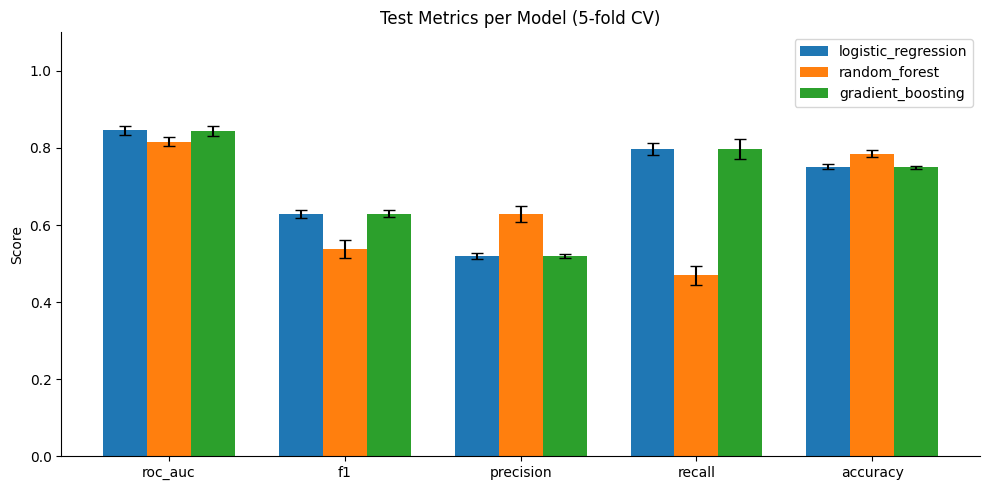

In [7]:
models = list(cv_results.keys())
metrics = scoring

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics))
width = 0.25

for i, model in enumerate(models):
    means = [cv_results[model][f"test_{m}"].mean() for m in metrics]
    stds = [cv_results[model][f"test_{m}"].std() for m in metrics]
    ax.bar(x + i * width, means, width, yerr=stds, label=model, capsize=4)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Test Metrics per Model (5-fold CV)")
ax.legend()
ax.set_ylim(0, 1.1)
sns.despine()
plt.tight_layout()
plt.show()

## Plot: overfitting check (train vs test ROC-AUC)

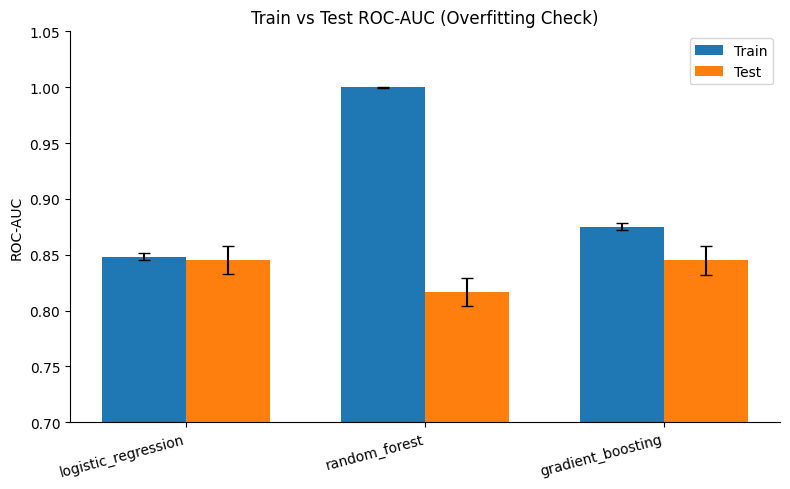

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(models))
width = 0.35

train_means = [cv_results[m]["train_roc_auc"].mean() for m in models]
test_means = [cv_results[m]["test_roc_auc"].mean() for m in models]
train_stds = [cv_results[m]["train_roc_auc"].std() for m in models]
test_stds = [cv_results[m]["test_roc_auc"].std() for m in models]

ax.bar(x - width / 2, train_means, width, yerr=train_stds, label="Train", capsize=4)
ax.bar(x + width / 2, test_means, width, yerr=test_stds, label="Test", capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha="right")
ax.set_ylabel("ROC-AUC")
ax.set_title("Train vs Test ROC-AUC (Overfitting Check)")
ax.legend()
ax.set_ylim(0.7, 1.05)
sns.despine()
plt.tight_layout()
plt.show()

## Plot: fold distribution (ROC-AUC box plots)

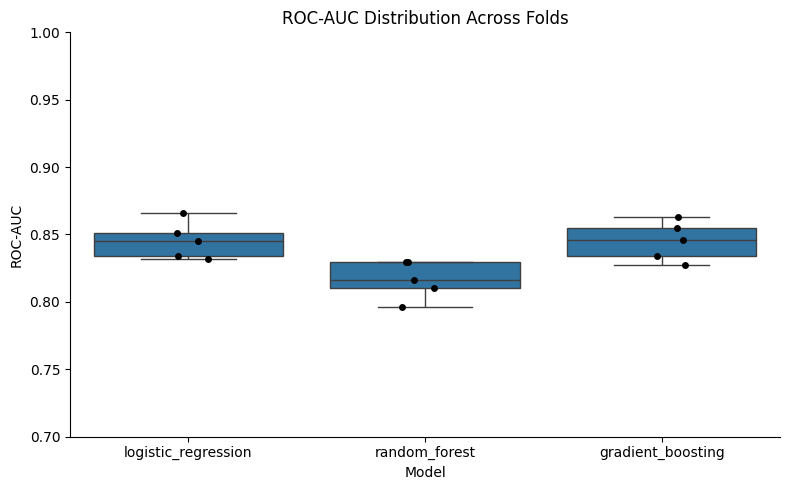

In [9]:
fold_data = []
for model in models:
    scores = cv_results[model]["test_roc_auc"]
    for score in scores:
        fold_data.append({"Model": model, "ROC-AUC": score})

fold_df = pd.DataFrame(fold_data)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=fold_df, x="Model", y="ROC-AUC", ax=ax)
sns.stripplot(data=fold_df, x="Model", y="ROC-AUC", color="black", size=5, ax=ax)
ax.set_title("ROC-AUC Distribution Across Folds")
ax.set_ylim(0.7, 1.0)
sns.despine()
plt.tight_layout()
plt.show()

## Best model selection

### Why ROC-AUC as the primary metric?

**ROC-AUC** measures the model's ability to **rank** churners above non-churners across
**all possible classification thresholds**. A score of 0.85 means that if we pick a random
churner and a random non-churner, the model assigns a higher churn probability to the
churner 85% of the time.

This is preferable at the baseline stage because:

- **Threshold-independent** -- It evaluates discrimination power without committing to a
  specific decision boundary. The optimal threshold depends on business costs
  (cost of retention offer vs cost of losing a customer) which we haven't defined yet.
- **Robust to class imbalance** -- With 26.5% churn, accuracy can be misleading
  (a naive "predict no churn" model gets 73.5% accuracy). ROC-AUC is unaffected by this.

**F1, precision, and recall** are included as secondary diagnostics. They are evaluated at the
default 0.5 threshold, which is almost certainly not the business-optimal cutoff.
Threshold optimization is a follow-up step where these metrics become central.

In [10]:
primary_metric = train_config["primary_metric"]
best_name = select_best_model(cv_results, primary_metric)
best_score = cv_results[best_name][primary_metric].mean()

print(f"Best model: {best_name}")
print(f"Metric: {primary_metric} = {best_score:.4f}")

Best model: logistic_regression
Metric: test_roc_auc = 0.8456


## Retrain on full data

In [11]:
best_pipeline = pipelines[best_name]
needs_sw = isinstance(best_pipeline.named_steps["model"], GradientBoostingClassifier)
fitted_pipeline = train_final_model(best_pipeline, X, y, needs_sample_weight=needs_sw)

# Sanity check
sample_preds = fitted_pipeline.predict(X.head())
sample_proba = fitted_pipeline.predict_proba(X.head())

print(f"Predictions (first 5): {sample_preds}")
print(f"Probabilities (first 5):\n{sample_proba}")
print(f"Actual (first 5): {y.head().values}")

Predictions (first 5): [1 0 1 0 1]
Probabilities (first 5):
[[0.18494164 0.81505836]
 [0.896281   0.103719  ]
 [0.40629235 0.59370765]
 [0.90310264 0.09689736]
 [0.1183614  0.8816386 ]]
Actual (first 5): [0 0 1 0 1]


## Confusion Matrix

Shows the actual counts of correct and incorrect predictions for each class.
Rows are the true labels, columns are the predicted labels.

**How to read it (for churn):**

|  | Predicted No Churn | Predicted Churn |
|---|---|---|
| **Actually No Churn** | True Negative (correctly kept) | False Positive (unnecessary retention offer) |
| **Actually Churn** | False Negative (missed churner) | True Positive (caught churner) |

The key tradeoff: **False Negatives** are lost customers (high cost), while **False Positives**
are wasted retention offers (lower cost). The business cost ratio between these two
determines the optimal classification threshold.

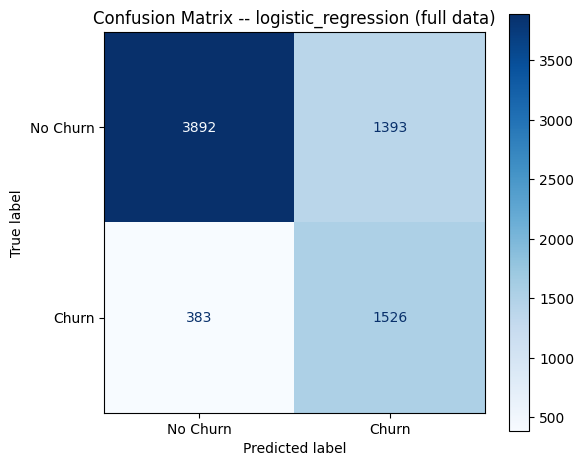


Quadrant                        Count % of total
--------------------------------------------------
True Negatives (correct No):     3892      54.1%
False Positives (false alarm):   1393      19.4%
False Negatives (missed churn):    383       5.3%
True Positives (caught churn):   1526      21.2%

Churn recall: 1526/1909 = 79.9% of churners are detected
Churn precision: 1526/2919 = 52.3% of churn predictions are correct

Business impact at default 0.5 threshold:
  - 383 churners are MISSED (no retention action taken)
  - 1393 non-churners receive unnecessary retention offers (wasted cost)
  --> Threshold tuning can shift this tradeoff based on business costs


In [12]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred = fitted_pipeline.predict(X)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y, y_pred, display_labels=["No Churn", "Churn"], cmap="Blues", ax=ax
)
ax.set_title(f"Confusion Matrix -- {best_name} (full data)")
plt.tight_layout()
plt.show()

# Interpretation
tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
total = len(y)

print(f"\n{'Quadrant':<30} {'Count':>6} {'% of total':>10}")
print("-" * 50)
print(f"{'True Negatives (correct No):':<30} {tn:>6} {tn / total:>10.1%}")
print(f"{'False Positives (false alarm):':<30} {fp:>6} {fp / total:>10.1%}")
print(f"{'False Negatives (missed churn):':<30} {fn:>6} {fn / total:>10.1%}")
print(f"{'True Positives (caught churn):':<30} {tp:>6} {tp / total:>10.1%}")
print()
print(f"Churn recall: {tp}/{tp + fn} = {tp / (tp + fn):.1%} of churners are detected")
print(f"Churn precision: {tp}/{tp + fp} = {tp / (tp + fp):.1%} of churn predictions are correct")
print()
print("Business impact at default 0.5 threshold:")
print(f"  - {fn} churners are MISSED (no retention action taken)")
print(f"  - {fp} non-churners receive unnecessary retention offers (wasted cost)")
print("  --> Threshold tuning can shift this tradeoff based on business costs")

## Classification Report

Per-class breakdown of precision, recall, and F1 at the default 0.5 threshold.
Shows how differently the model treats each class.

In [13]:
from sklearn.metrics import classification_report

print(classification_report(y, y_pred, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      5285
       Churn       0.52      0.80      0.63      1909

    accuracy                           0.75      7194
   macro avg       0.72      0.77      0.72      7194
weighted avg       0.81      0.75      0.77      7194



## Learning Curve

Plots train and test ROC-AUC as a function of training set size.
Answers two questions:
- **Do we have enough data?** If the test curve is still rising, more data could help.
- **Is the model underfitting or overfitting?** A large gap between train and test indicates
  overfitting; converging curves at a low score indicate underfitting.

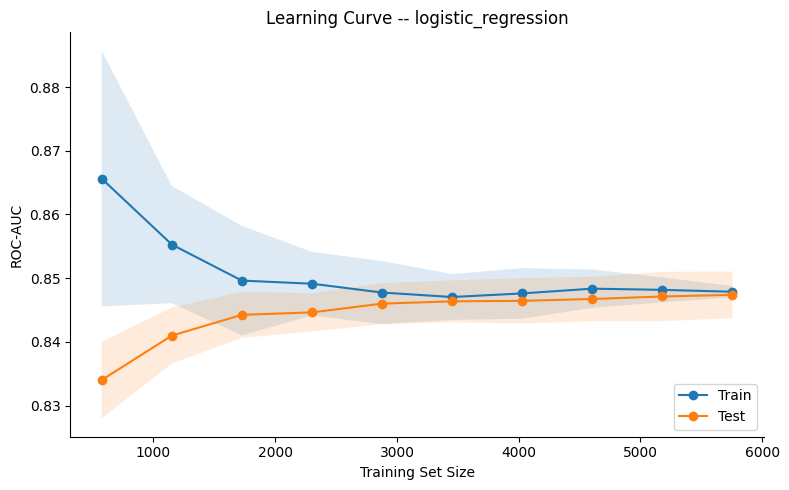

In [14]:
from sklearn.model_selection import ShuffleSplit, learning_curve

# Build a fresh pipeline for learning curve (needs unfitted estimator)
fresh_pipelines = build_model_pipelines(feature_config, train_config)
best_fresh = fresh_pipelines[best_name]

cv_lc = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    best_fresh,
    X,
    y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv_lc,
    scoring="roc_auc",
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15)
ax.plot(train_sizes, train_mean, "o-", label="Train")
ax.plot(train_sizes, test_mean, "o-", label="Test")
ax.set_xlabel("Training Set Size")
ax.set_ylabel("ROC-AUC")
ax.set_title(f"Learning Curve -- {best_name}")
ax.legend(loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()

## Save artifacts

In [15]:
model_path = save_model(
    fitted_pipeline,
    train_config["model_output_path"],
    train_config["best_pipeline_filename"],
)
print(f"Saved model to: {model_path}")

results_path = save_cv_results(
    cv_results,
    best_name,
    train_config["reporting_output_path"],
    train_config["cv_results_filename"],
)
print(f"Saved CV results to: {results_path}")

Saved model to: data/06_models/Churn/churn_best_pipeline.joblib
Saved CV results to: data/08_reporting/Churn/cv_results.json


## 📊 Analysis of Results and Conclusions

### Baseline model comparison (5-fold Stratified CV)

| Model | ROC-AUC | F1 | Precision | Recall | Accuracy | Overfitting |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.8456 | 0.6294 | 0.5198 | 0.7978 | 0.7508 | Low (train ~0.848) |
| Gradient Boosting | 0.8451 | 0.6290 | 0.5191 | 0.7983 | 0.7502 | Low (train ~0.875) |
| Random Forest | 0.8164 | 0.5374 | 0.6278 | 0.4699 | 0.7855 | High (train ~1.000) |

**Key findings:**
- Logistic Regression and Gradient Boosting are nearly tied on test ROC-AUC
- Random Forest severely overfits (train ROC-AUC ~1.0 vs test ~0.82)
- Logistic Regression is selected as the baseline winner due to marginally higher ROC-AUC, simplicity, and no overfitting
- The 26.5% churn imbalance is handled via `class_weight='balanced'` (LR, RF) and `compute_sample_weight` (GB)
- All models show stable CV scores (low std across folds)
- **Precision/recall tradeoff across models:** Random Forest has a very different behavior from LR and GB. RF favors precision (0.63) over recall (0.47), meaning it makes fewer false churn predictions but misses over half of actual churners. LR and GB favor recall (0.80) over precision (0.52), catching ~80% of churners but with nearly half of churn predictions being wrong. This reflects fundamentally different decision boundaries and matters when choosing a model depending on business costs
- **Confusion matrix at 0.5 threshold (LR on full data):** Churn precision is only 52.3%, meaning nearly half of churn predictions are wrong (false alarms). Recall is 79.9%, catching ~80% of churners but still missing 383. Overall accuracy is 75.1%, only marginally above the naive baseline of 73.5% (predicting all as No Churn). This confirms that the default 0.5 threshold is suboptimal and motivates threshold optimization as the next step

### Pipeline architecture and inference implications

The saved `.joblib` artifact contains the **complete sklearn Pipeline** with all preprocessing
embedded:

```
Pipeline steps: ['preprocessor', 'scaler', 'model']
```

- **preprocessor** (`ColumnTransformer`): imputation, `ServiceLevelConsolidator`,
  `OneHotEncoder`, `OrdinalEncoder`, `NewCustomerTransformer` -- all feature engineering
  happens inside this step
- **scaler** (`StandardScaler`): normalizes features for Logistic Regression
- **model** (`LogisticRegression`): the trained classifier

**What this means for deployment:**

- At inference time, pass the **16 raw primary columns** directly (the same schema as
  `data/03_primary/`). The pipeline applies all transformations internally.
- The `data/04_feature/` layer (22 engineered features) is **not needed** at inference --
  it was only used for exploratory analysis during training.
- No separate preprocessing step is required. A single `pipeline.predict_proba(X)` call
  handles everything from raw input to probability output.

## 💡 Proposals and Ideas

1. **Hyperparameter tuning** -- Grid/random search on the top 2 models (LR and GB) to improve beyond baseline
2. **Threshold optimization** -- Default 0.5 threshold may not be optimal for the business case; optimize for F1 or cost-based metric
3. **Feature importance analysis** -- Identify the most predictive features to guide business decisions
4. **Calibration** -- Check if predicted probabilities are well-calibrated for risk scoring
5. **Ensemble methods** -- Combine LR and GB predictions for potentially better performance

## 📖 References

- [scikit-learn cross_validate](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html)
- [Handling imbalanced classes](https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_sample_weight.html)